# Estrategia de medias móviles

En este notebook empiezo a construir la primera estrategia activa del proyecto QuantLab.

La idea básica es comparar dos medias móviles del precio de SPY:

- una media móvil corta;
- una media móvil larga.

En este primer día del sprint solo calcularé y visualizaré las medias móviles. Todavía no ejecutaré el backtest completo.

El objetivo es entender visualmente cómo se comportan las medias móviles respecto al precio.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

print("Imports básicos cargados correctamente")

Imports básicos cargados correctamente


## Imports básicos

En este notebook uso:

- `pandas` para trabajar con tablas, series temporales y datos financieros;
- `numpy` para cálculos numéricos;
- `matplotlib.pyplot` para gráficos;
- `Path` para construir rutas de archivos de forma robusta;
- `sys` para poder importar funciones desde la carpeta `src`.

In [2]:
cwd = Path.cwd()

if (cwd / "requirements.txt").exists():
    project_root = cwd
else:
    project_root = cwd.parent

project_root

WindowsPath('c:/Users/usuario/Documents/GitHub/QuantLab')

## Raíz del proyecto

Localizo la carpeta principal del proyecto para poder construir rutas relativas de forma estable.

Esto evita depender de desde qué carpeta exacta se esté ejecutando el notebook.

In [3]:
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

src_path

WindowsPath('c:/Users/usuario/Documents/GitHub/QuantLab/src')

## Importar código propio

La carpeta `src/` contiene funciones reutilizables creadas en sprints anteriores.

Para poder importarlas desde el notebook, añado esa carpeta al path de Python.

In [4]:
from backtester import (
    calculate_strategy_returns,
    calculate_equity_curve,
    run_backtest,
    compare_equity_curves,
    validate_inputs,
)

from metrics import (
    total_return,
    annualized_return,
    annualized_volatility,
    drawdown,
    max_drawdown,
    performance_summary,
)

print("Funciones propias importadas correctamente")

Funciones propias importadas correctamente


## Funciones propias importadas

Importo las funciones creadas en el Sprint 2.

Aunque en el Día 1 todavía no necesito ejecutar el backtest completo, dejo importadas las funciones principales porque este notebook crecerá durante el Sprint 3.

Las funciones de `backtester.py` servirán para ejecutar la estrategia cuando tengamos posiciones.

Las funciones de `metrics.py` servirán para evaluar la estrategia más adelante.

In [5]:
processed_file = project_root / "data" / "processed" / "SPY_daily.csv"
raw_file = project_root / "data" / "raw" / "SPY_daily.csv"
raw_file_alt = project_root / "data" / "raw" / "SPY_daily_raw.csv"

if processed_file.exists():
    data_file = processed_file
elif raw_file.exists():
    data_file = raw_file
elif raw_file_alt.exists():
    data_file = raw_file_alt
else:
    raise FileNotFoundError("No encuentro el CSV de SPY.")

print("Archivo usado:", data_file)

Archivo usado: c:\Users\usuario\Documents\GitHub\QuantLab\data\processed\SPY_daily.csv


## Archivo de datos

Uso el archivo de datos de SPY descargado en el Sprint 1.

Doy prioridad a la versión procesada si existe. Si no existe, uso la versión guardada en `data/raw`.

In [6]:
spy = pd.read_csv(data_file, index_col=0, parse_dates=True)

spy.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
1993-01-29,24.113268,43.93750,43.96875,43.75000,43.96875,1003200
1993-02-01,24.284761,44.25000,44.25000,43.96875,43.96875,480500
1993-02-02,24.336224,44.34375,44.37500,44.12500,44.21875,201300
1993-02-03,24.593477,44.81250,44.84375,44.37500,44.40625,529400
1993-02-04,24.696363,45.00000,45.09375,44.46875,44.96875,531500


In [7]:
spy.tail()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-06-26,728.989990,728.989990,736.530029,716.580017,728.950012,71034000
2026-06-29,741.000000,741.000000,741.559998,732.090027,736.530029,58035200
2026-06-30,746.770020,746.770020,748.020020,740.890015,741.289978,55626000
2026-07-01,745.760010,745.760010,749.440002,742.380005,745.000000,47100900
2026-07-02,744.780029,744.780029,751.309998,740.030029,747.400024,57447800


In [8]:
spy.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 8413 entries, 1993-01-29 to 2026-07-02
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  8413 non-null   float64
 1   Close      8413 non-null   float64
 2   High       8413 non-null   float64
 3   Low        8413 non-null   float64
 4   Open       8413 non-null   float64
 5   Volume     8413 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 460.1 KB


## Lectura de datos

Leo el CSV de SPY usando la primera columna como índice de fechas.

El argumento `parse_dates=True` intenta convertir el índice en fechas, lo cual es importante porque estamos trabajando con una serie temporal.

In [9]:
price = spy["Adj Close"].copy()

price.head()

Date
1993-01-29    24.113268
1993-02-01    24.284761
1993-02-02    24.336224
1993-02-03    24.593477
1993-02-04    24.696363
Name: Adj Close, dtype: float64

In [10]:
type(price)

pandas.Series

## Precio ajustado

Trabajo con `Adj Close`, el precio ajustado.

Este precio es más apropiado para calcular rentabilidades históricas porque incorpora ajustes como dividendos y splits.

Guardo la columna como una `pd.Series` llamada `price`.

In [11]:
returns = price.pct_change().dropna()

returns.head()

Date
1993-02-01    0.007112
1993-02-02    0.002119
1993-02-03    0.010571
1993-02-04    0.004183
1993-02-05   -0.000694
Name: Adj Close, dtype: float64

In [12]:
returns.describe()

count    8412.000000
mean        0.000476
std         0.011700
min        -0.109424
25%        -0.004316
50%         0.000683
75%         0.005948
max         0.145198
Name: Adj Close, dtype: float64

## Rendimientos diarios

Calculo los rendimientos diarios simples a partir del precio ajustado.

La fórmula es:

\[
R_t = \frac{P_t}{P_{t-1}} - 1
\]

Estos rendimientos serán la entrada principal del backtester cuando ejecutemos la estrategia.

In [13]:
short_window = 20
long_window = 100

short_window, long_window

(20, 100)

## Ventanas de medias móviles

Voy a usar dos ventanas iniciales:

- media móvil corta: 20 días;
- media móvil larga: 100 días.

La media de 20 días representa una tendencia más rápida.

La media de 100 días representa una tendencia más lenta.

In [14]:
short_ma = price.rolling(window=short_window).mean()
long_ma = price.rolling(window=long_window).mean()

short_ma.head(25)

Date
1993-01-29          NaN
1993-02-01          NaN
1993-02-02          NaN
1993-02-03          NaN
1993-02-04          NaN
1993-02-05          NaN
1993-02-08          NaN
1993-02-09          NaN
1993-02-10          NaN
1993-02-11          NaN
1993-02-12          NaN
1993-02-16          NaN
1993-02-17          NaN
1993-02-18          NaN
1993-02-19          NaN
1993-02-22          NaN
1993-02-23          NaN
1993-02-24          NaN
1993-02-25          NaN
1993-02-26    24.297628
1993-03-01    24.307060
1993-03-02    24.325926
1993-03-03    24.347363
1993-03-04    24.349078
1993-03-05    24.342218
Name: Adj Close, dtype: float64

In [15]:
long_ma.head(105)

Date
1993-01-29          NaN
1993-02-01          NaN
1993-02-02          NaN
1993-02-03          NaN
1993-02-04          NaN
                ...    
1993-06-23    24.609955
1993-06-24    24.615955
1993-06-25    24.621267
1993-06-28    24.626782
1993-06-29    24.630055
Name: Adj Close, Length: 105, dtype: float64

## Medias móviles

Calculo las medias móviles usando `.rolling(window).mean()`.

Una media móvil de 20 días calcula, para cada fecha, la media de los últimos 20 precios disponibles.

Una media móvil de 100 días hace lo mismo, pero usando los últimos 100 precios.

Por eso al principio aparecen valores `NaN`: todavía no hay suficientes datos para llenar la ventana.

In [16]:
ma_data = pd.DataFrame({
    "price": price,
    "short_ma": short_ma,
    "long_ma": long_ma,
})

ma_data.head(110)

,price,short_ma,long_ma
Date,,,
1993-01-29,24.113268,NaN,NaN
1993-02-01,24.284761,NaN,NaN
1993-02-02,24.336224,NaN,NaN
1993-02-03,24.593477,NaN,NaN
1993-02-04,24.696363,NaN,NaN
...,...,...,...
1993-06-30,25.023575,24.852108,24.633498
1993-07-01,24.954165,24.847105,24.636247
1993-07-02,24.815323,24.839466,24.639323


In [17]:
ma_data.isna().sum()

price        0
short_ma    19
long_ma     99
dtype: int64

## Tabla de revisión

Construyo una tabla con el precio y las dos medias móviles.

Esta tabla me permite comprobar cuándo empiezan a aparecer valores válidos en cada media móvil.

La media móvil de 20 días empieza antes que la de 100 días porque necesita menos observaciones.

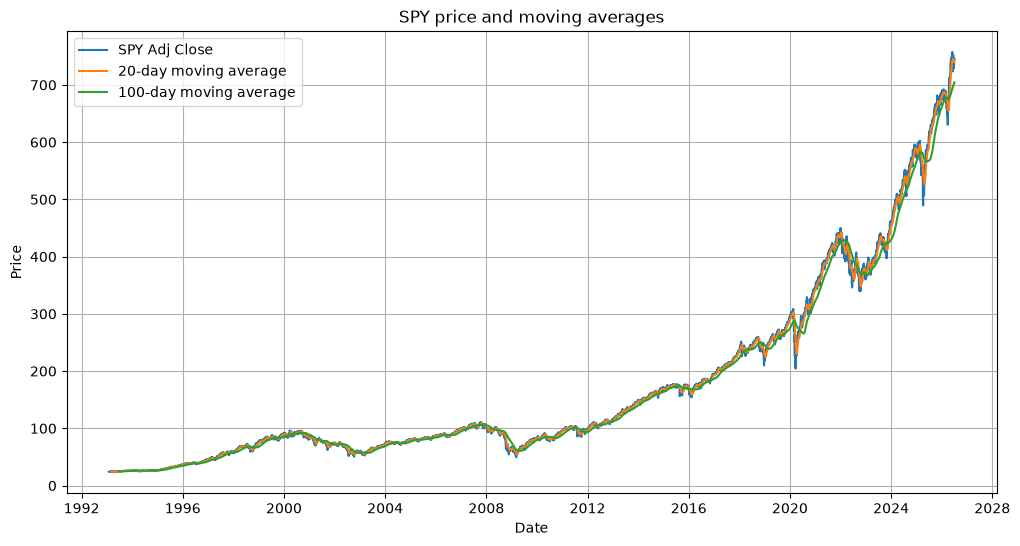

In [18]:
plt.figure(figsize=(12, 6))

plt.plot(ma_data.index, ma_data["price"], label="SPY Adj Close")
plt.plot(ma_data.index, ma_data["short_ma"], label=f"{short_window}-day moving average")
plt.plot(ma_data.index, ma_data["long_ma"], label=f"{long_window}-day moving average")

plt.title("SPY price and moving averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

## Visualización completa

En este gráfico comparo el precio de SPY con sus medias móviles.

La media móvil corta se mueve más cerca del precio.

La media móvil larga es más suave y reacciona más lentamente.

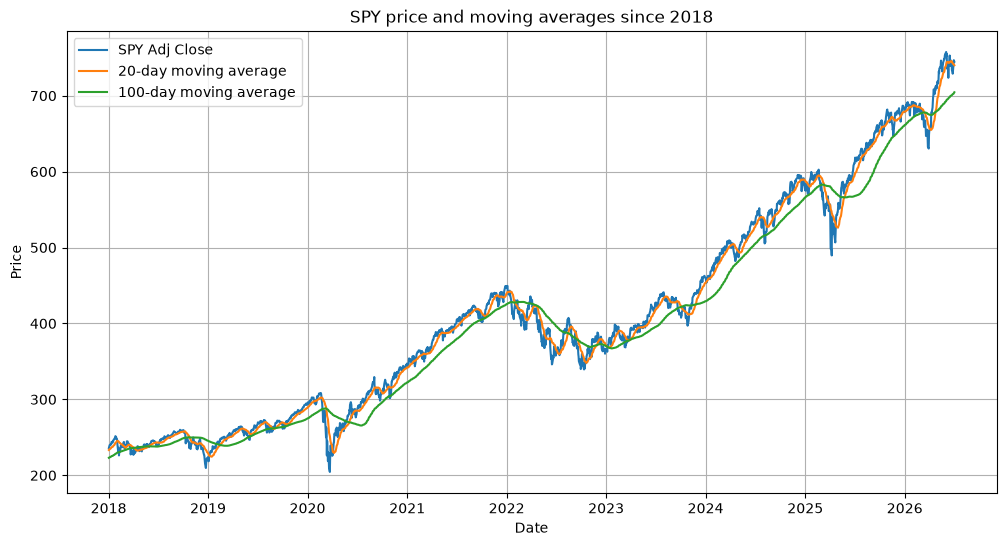

In [19]:
recent_ma_data = ma_data.loc["2018":].copy()

plt.figure(figsize=(12, 6))

plt.plot(recent_ma_data.index, recent_ma_data["price"], label="SPY Adj Close")
plt.plot(recent_ma_data.index, recent_ma_data["short_ma"], label=f"{short_window}-day moving average")
plt.plot(recent_ma_data.index, recent_ma_data["long_ma"], label=f"{long_window}-day moving average")

plt.title("SPY price and moving averages since 2018")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

## Análisis visual

1. ¿Cuál de las dos medias móviles reacciona más rápido al precio?

La media corta, es más sensible a los cambios porque tiene menos inputs.

2. ¿Cuál de las dos medias móviles es más suave?

La larga, por el mismo motivo

3. ¿Qué parece ocurrir cuando el precio entra en una tendencia bajista fuerte?

La media larga se mantiene más constante y la corta baja con el precio

4. ¿Qué podría significar que la media corta esté por encima de la media larga?

Significa que hay una tendencia creciente

5. ¿Qué podría significar que la media corta esté por debajo de la media larga?

Que hay una tendencia decreciente

In [20]:
def moving_average(series: pd.Series, window: int) -> pd.Series:
    """
    Calculate the moving average of a pandas Series.

    Parameters
    ----------
    series : pd.Series
        Input time series.
    window : int
        Number of observations used to calculate the moving average.

    Returns
    -------
    pd.Series
        Moving average of the input series.
    """
    if not isinstance(series, pd.Series):
        raise TypeError("series must be a pandas Series")

    if not isinstance(window, int):
        raise TypeError("window must be an integer")

    if window <= 0:
        raise ValueError("window must be positive")

    return series.rolling(window=window).mean()

In [21]:
short_ma_function = moving_average(price, short_window)
long_ma_function = moving_average(price, long_window)

short_ma_function.head()

Date
1993-01-29   NaN
1993-02-01   NaN
1993-02-02   NaN
1993-02-03   NaN
1993-02-04   NaN
Name: Adj Close, dtype: float64

In [22]:
(short_ma - short_ma_function).abs().max()

np.float64(0.0)

In [23]:
(long_ma - long_ma_function).abs().max()

np.float64(0.0)

## Tarea extra

He creado una función `moving_average` que encapsula el cálculo de una media móvil.

La función recibe una serie temporal y una ventana, valida los inputs básicos y devuelve la media móvil calculada con `.rolling(window).mean()`.

Esto permite reutilizar el cálculo y evita repetir la misma línea de código varias veces.

In [24]:
sys.path

['C:\\Users\\usuario\\anaconda3\\python311.zip',
 'C:\\Users\\usuario\\anaconda3\\DLLs',
 'C:\\Users\\usuario\\anaconda3\\Lib',
 'C:\\Users\\usuario\\anaconda3',
 'c:\\Users\\usuario\\Documents\\GitHub\\QuantLab\\.venv',
 '',
 'c:\\Users\\usuario\\Documents\\GitHub\\QuantLab\\.venv\\Lib\\site-packages',
 'c:\\Users\\usuario\\Documents\\GitHub\\QuantLab\\src']

# Día 2 — Señales y posiciones

En esta sección convierto las medias móviles en una señal de trading.

La idea de la estrategia es sencilla:

- si la media móvil corta está por encima de la media móvil larga, interpreto que hay una tendencia positiva;
- si la media móvil corta está por debajo de la media móvil larga, interpreto que no quiero estar invertido.

A partir de esa señal construiré una serie de posiciones:

- `1` significa estar invertido;
- `0` significa estar fuera del mercado.

In [25]:
signal = short_ma > long_ma

signal.head(110)

Date
1993-01-29    False
1993-02-01    False
1993-02-02    False
1993-02-03    False
1993-02-04    False
              ...  
1993-06-30     True
1993-07-01     True
1993-07-02     True
1993-07-06     True
1993-07-07     True
Name: Adj Close, Length: 110, dtype: bool

## Señal de medias móviles

Creo una señal comparando la media móvil corta con la media móvil larga.

La señal vale `True` cuando la media corta está por encima de la media larga.

La señal vale `False` cuando la media corta está por debajo de la media larga.

In [26]:
valid_ma = short_ma.notna() & long_ma.notna()

valid_ma.head(110)

Date
1993-01-29    False
1993-02-01    False
1993-02-02    False
1993-02-03    False
1993-02-04    False
              ...  
1993-06-30     True
1993-07-01     True
1993-07-02     True
1993-07-06     True
1993-07-07     True
Name: Adj Close, Length: 110, dtype: bool

## Periodo inicial sin medias móviles

La media móvil de 100 días necesita 100 observaciones para empezar a existir.

Antes de que existan ambas medias móviles, la estrategia no debería tomar decisiones.

Por eso creo `valid_ma`, que indica cuándo existen tanto la media corta como la media larga.

In [27]:
position_on_price_index = pd.Series(0, index=price.index)

position_on_price_index.head()

Date
1993-01-29    0
1993-02-01    0
1993-02-02    0
1993-02-03    0
1993-02-04    0
dtype: int64

In [28]:
position_on_price_index[valid_ma & signal] = 1

position_on_price_index.head(110)

Date
1993-01-29    0
1993-02-01    0
1993-02-02    0
1993-02-03    0
1993-02-04    0
             ..
1993-06-30    1
1993-07-01    1
1993-07-02    1
1993-07-06    1
1993-07-07    1
Length: 110, dtype: int64

In [29]:
returns = price.pct_change().dropna()

In [30]:
position = position_on_price_index.loc[returns.index].copy()

position.head()

Date
1993-02-01    0
1993-02-02    0
1993-02-03    0
1993-02-04    0
1993-02-05    0
dtype: int64

In [31]:
returns.index.equals(position.index)

True

In [32]:
returns.index

DatetimeIndex(['1993-02-01', '1993-02-02', '1993-02-03', '1993-02-04',
               '1993-02-05', '1993-02-08', '1993-02-09', '1993-02-10',
               '1993-02-11', '1993-02-12',
               ...
               '2026-06-18', '2026-06-22', '2026-06-23', '2026-06-24',
               '2026-06-25', '2026-06-26', '2026-06-29', '2026-06-30',
               '2026-07-01', '2026-07-02'],
              dtype='datetime64[us]', name='Date', length=8412, freq=None)

## Alineación entre rendimientos y posiciones

El backtester necesita que `returns` y `position` tengan exactamente el mismo índice.

Como `returns` empieza un día después que `price`, alineo la posición usando el índice de `returns`.

Esto garantiza que cada rendimiento diario y cada posición correspondan a las mismas fechas.

In [33]:
validate_inputs(returns, position)

print("Inputs válidos para el backtester")

Inputs válidos para el backtester


## Validación de inputs

Uso `validate_inputs` para comprobar que `returns` y `position` son compatibles.

La función comprueba que ambas variables son `pd.Series`, que tienen el mismo índice y que no contienen valores nulos.

In [34]:
strategy_data = pd.DataFrame({
    "price": price,
    "short_ma": short_ma,
    "long_ma": long_ma,
    "signal": signal,
    "position": position_on_price_index,
    "returns": returns,
})

strategy_data.head(110)

,price,short_ma,long_ma,signal,position,returns
Date,,,,,,
1993-01-29,24.113268,NaN,NaN,False,0,NaN
1993-02-01,24.284761,NaN,NaN,False,0,0.007112
1993-02-02,24.336224,NaN,NaN,False,0,0.002119
1993-02-03,24.593477,NaN,NaN,False,0,0.010571
1993-02-04,24.696363,NaN,NaN,False,0,0.004183
...,...,...,...,...,...,...
1993-06-30,25.023575,24.852108,24.633498,True,1,0.000000
1993-07-01,24.954165,24.847105,24.636247,True,1,-0.002774
1993-07-02,24.815323,24.839466,24.639323,True,1,-0.005564


In [35]:
strategy_data.tail()

,price,short_ma,long_ma,signal,position,returns
Date,,,,,,
2026-06-26,728.989990,742.259274,702.022377,True,1,-0.007231
2026-06-29,741.000000,741.582468,702.573527,True,1,0.016475
2026-06-30,746.770020,741.091428,703.215601,True,1,0.007787
2026-07-01,745.760010,740.498517,703.932821,True,1,-0.001353
2026-07-02,744.780029,740.122424,704.510929,True,1,-0.001314


In [36]:
strategy_data.isna().sum()

price        0
short_ma    19
long_ma     99
signal       0
position     0
returns      1
dtype: int64

## Tabla de revisión de la estrategia

Creo una tabla con el precio, las medias móviles, la señal, la posición y los rendimientos.

Esta tabla me permite comprobar manualmente que la posición cambia cuando la relación entre las medias móviles cambia.

In [37]:
position_changes = strategy_data[
    strategy_data["position"].diff().fillna(0) != 0
]

position_changes.head(20)

,price,short_ma,long_ma,signal,position,returns
Date,,,,,,
1993-06-22,24.780621,24.890830,24.605538,True,1,0.000701
1994-03-29,25.515762,26.317494,26.332898,False,0,-0.019701
1994-06-16,26.276112,26.021935,26.005576,True,1,0.002022
1994-06-30,25.328476,25.870825,25.882966,False,0,-0.006285
1994-08-01,26.271851,25.768125,25.736737,True,1,0.004766
1994-12-01,25.867531,26.463418,26.488462,False,0,-0.009938
1995-01-13,26.994364,26.576387,26.575185,True,1,0.011840
1996-07-23,37.403587,38.923226,38.958695,False,0,-0.012795
1996-08-21,39.734329,39.201054,39.107820,True,1,-0.003507


## Cambios de posición

Busco las fechas donde la posición cambia.

Estos cambios representan posibles entradas o salidas de la estrategia.

Un cambio de `0` a `1` significa que la estrategia pasa a estar invertida.

Un cambio de `1` a `0` significa que la estrategia sale del mercado.

In [38]:
first_change_date = position_changes.index[0]

first_change_date

Timestamp('1993-06-22 00:00:00')

In [39]:
strategy_data.loc[
    first_change_date - pd.Timedelta(days=10):
    first_change_date + pd.Timedelta(days=10)
]

,price,short_ma,long_ma,signal,position,returns
Date,,,,,,
1993-06-14,24.830238,24.844885,NaN,False,0,-0.001386
1993-06-15,24.778538,24.866424,NaN,False,0,-0.002082
1993-06-16,24.830238,24.891409,NaN,False,0,0.002087
1993-06-17,24.916405,24.895717,NaN,False,0,0.003470
1993-06-18,24.711195,24.886319,NaN,False,0,-0.008236
1993-06-21,24.763271,24.890725,NaN,False,0,0.002107
1993-06-22,24.780621,24.890830,24.605538,True,1,0.000701
1993-06-23,24.555037,24.877069,24.609955,True,1,-0.009103
1993-06-24,24.884735,24.864286,24.615955,True,1,0.013427


## Revisión manual de un cambio de posición

He revisado una ventana alrededor del primer cambio de posición.

En esa zona se observa que la posición cambia cuando cambia la relación entre la media corta y la media larga.

Esto confirma que la señal está funcionando según la regla definida.

In [40]:
recent_strategy_data = strategy_data.loc["2018":].copy()

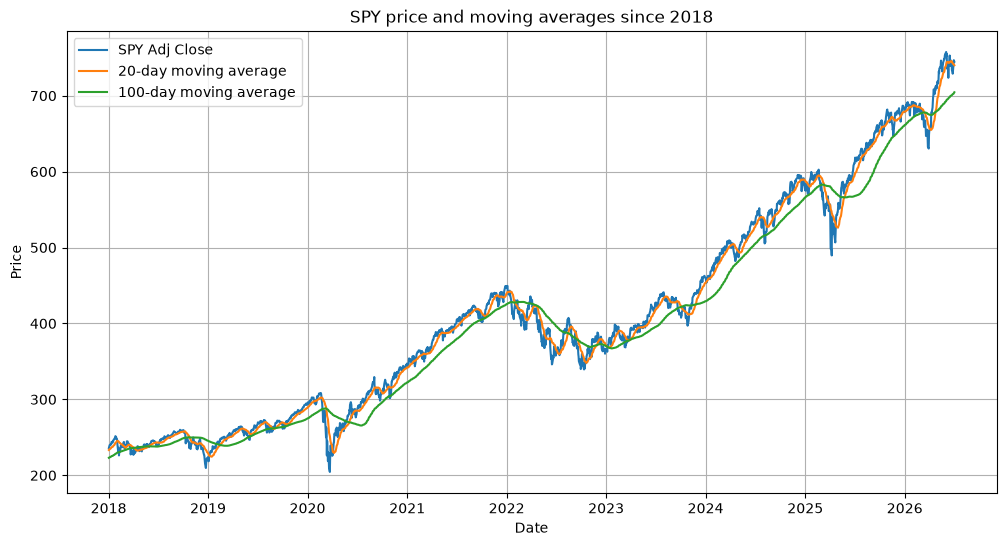

In [41]:
plt.figure(figsize=(12, 6))

plt.plot(recent_strategy_data.index, recent_strategy_data["price"], label="SPY Adj Close")
plt.plot(recent_strategy_data.index, recent_strategy_data["short_ma"], label=f"{short_window}-day moving average")
plt.plot(recent_strategy_data.index, recent_strategy_data["long_ma"], label=f"{long_window}-day moving average")

plt.title("SPY price and moving averages since 2018")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

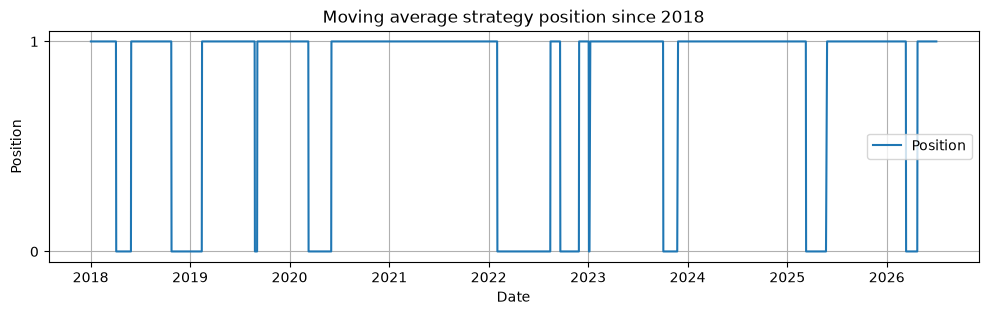

In [42]:
plt.figure(figsize=(12, 3))

plt.plot(recent_strategy_data.index, recent_strategy_data["position"], label="Position")

plt.title("Moving average strategy position since 2018")
plt.xlabel("Date")
plt.ylabel("Position")
plt.yticks([0, 1])
plt.legend()
plt.grid(True)
plt.show()

In [43]:
time_in_market = position.mean()

time_in_market

np.float64(0.7326438421302901)

In [44]:
time_in_market * 100

np.float64(73.264384213029)

## Tiempo en mercado

La media de la serie `position` indica qué porcentaje del tiempo está invertida la estrategia.

Como la posición solo puede valer `0` o `1`, su media se interpreta como proporción de días invertidos.

## Análisis del Día 2

1. ¿Qué representa `signal`?

Signal es una sere de booleanos indexada por las fechas, que es true si la media corta es mayor que la larga y false en caso contrario.

2. ¿Qué representa `position`?

Position es nuestra posición de mercado deducida a partir de signal (y de que las dos medias existan), con un 1 estando invertidos y un 0 en otro caso

3. ¿Por qué no basta con calcular medias móviles para tener una estrategia?

Porque para tener una estrategia necesitamos tomar una decisión de si invertir o no en función de esas medias móviles

4. ¿Por qué es importante alinear `position` con `returns`?

Para que vayamos acordes con las fechas para las que estamos calculando las medias, y así saber exactamente qué beneficios obtenemos con la estrategia

5. ¿Qué porcentaje aproximado del tiempo está invertida la estrategia?

El 73 por ciento de los días

6. Mirando el gráfico, ¿la estrategia parece estar más tiempo dentro o fuera del mercado?

Parece estar más tiempo dentro. Eso significa que, bajo nuestro criterio de comparación de medias, el activo tiene en la mayor parte del tiempo una tendencia alcista.

In [46]:
def create_moving_average_position(
    price: pd.Series,
    short_window: int,
    long_window: int,
) -> pd.Series:
    """
    Create a long-only moving average position.

    Parameters
    ----------
    price : pd.Series
        Price series.
    short_window : int
        Window used for the short moving average.
    long_window : int
        Window used for the long moving average.

    Returns
    -------
    pd.Series
        Position series indexed like price.
        1 means invested, 0 means out of the market.
    """
    if not isinstance(price, pd.Series):
        raise TypeError("price must be a pandas Series")

    if not isinstance(short_window, int):
        raise TypeError("short_window must be an integer")

    if not isinstance(long_window, int):
        raise TypeError("long_window must be an integer")

    if short_window <= 0:
        raise ValueError("short_window must be positive")

    if long_window <= 0:
        raise ValueError("long_window must be positive")

    if short_window >= long_window:
        raise ValueError("short_window must be smaller than long_window")

    short_ma = price.rolling(window=short_window).mean()
    long_ma = price.rolling(window=long_window).mean()

    signal = short_ma > long_ma
    valid_ma = short_ma.notna() & long_ma.notna()

    position = pd.Series(0, index=price.index)
    position[valid_ma & signal] = 1

    return position

In [47]:
position_function = create_moving_average_position(
    price=price,
    short_window=short_window,
    long_window=long_window,
)

position_function.head(110)

Date
1993-01-29    0
1993-02-01    0
1993-02-02    0
1993-02-03    0
1993-02-04    0
             ..
1993-06-30    1
1993-07-01    1
1993-07-02    1
1993-07-06    1
1993-07-07    1
Length: 110, dtype: int64

In [48]:
position_from_function = position_function.loc[returns.index].copy()

validate_inputs(returns, position_from_function)

print("Position from function is valid")

Position from function is valid


# Día 3 — Backtest de la estrategia de medias móviles

En esta sección ejecuto el backtest de la estrategia de medias móviles.

La estrategia ya tiene una serie de posiciones:

- `1` significa estar invertido en SPY;
- `0` significa estar fuera del mercado.

Ahora uso `run_backtest` para convertir esas posiciones en rendimientos de estrategia y curva de capital.

In [49]:
ma_position_on_price_index = create_moving_average_position(
    price=price,
    short_window=short_window,
    long_window=long_window,
)

ma_position_on_price_index.head(110)

Date
1993-01-29    0
1993-02-01    0
1993-02-02    0
1993-02-03    0
1993-02-04    0
             ..
1993-06-30    1
1993-07-01    1
1993-07-02    1
1993-07-06    1
1993-07-07    1
Length: 110, dtype: int64

In [50]:
ma_position = ma_position_on_price_index.loc[returns.index].copy()

ma_position.head()

Date
1993-02-01    0
1993-02-02    0
1993-02-03    0
1993-02-04    0
1993-02-05    0
dtype: int64

In [51]:
validate_inputs(returns, ma_position)

print("Inputs válidos para la estrategia de medias móviles")

Inputs válidos para la estrategia de medias móviles


## Posición de la estrategia

Reconstruyo la posición de la estrategia usando la función `create_moving_average_position`.

Después alineo la posición con el índice de `returns`, porque el backtester necesita que ambas series tengan exactamente las mismas fechas.

In [52]:
ma_strategy_returns, ma_equity = run_backtest(
    returns=returns,
    position=ma_position,
)

ma_strategy_returns.head()

Date
1993-02-02    0.0
1993-02-03    0.0
1993-02-04    0.0
1993-02-05   -0.0
1993-02-08    0.0
dtype: float64

In [53]:
ma_equity.head()

Date
1993-02-02    1.0
1993-02-03    1.0
1993-02-04    1.0
1993-02-05    1.0
1993-02-08    1.0
dtype: float64

In [54]:
ma_equity.tail()

Date
2026-06-26    8.669718
2026-06-29    8.812550
2026-06-30    8.881172
2026-07-01    8.869160
2026-07-02    8.857505
dtype: float64

## Ejecución del backtest

Ejecuto el backtest usando `run_backtest`.

La función recibe:

- los rendimientos diarios de SPY;
- la posición diaria de la estrategia.

Devuelve:

- `ma_strategy_returns`: rendimientos diarios capturados por la estrategia;
- `ma_equity`: curva de capital de la estrategia.

In [55]:
backtest_check = pd.DataFrame({
    "returns": returns,
    "position": ma_position,
    "position_shifted": ma_position.shift(1),
    "strategy_returns": ma_strategy_returns,
    "equity": ma_equity,
})

backtest_check.head(120)

,returns,position,position_shifted,strategy_returns,equity
Date,,,,,
1993-02-01,0.007112,0,NaN,NaN,NaN
1993-02-02,0.002119,0,0.0,0.000000,1.000000
1993-02-03,0.010571,0,0.0,0.000000,1.000000
1993-02-04,0.004183,0,0.0,0.000000,1.000000
1993-02-05,-0.000694,0,0.0,-0.000000,1.000000
...,...,...,...,...,...
1993-07-16,-0.002786,1,1.0,-0.002786,1.002800
1993-07-19,-0.000697,1,1.0,-0.000697,1.002101
1993-07-20,0.002795,1,1.0,0.002795,1.004902


## Revisión del mecanismo del backtest

La columna `position` muestra la posición calculada para cada fecha.

La columna `position_shifted` muestra la posición desplazada un día.

El backtester usa `position_shifted * returns`, porque la posición decidida con información disponible hasta ayer se aplica al rendimiento de hoy.

Esto evita usar información futura.

In [56]:
ma_summary = performance_summary(
    equity_curve=ma_equity,
    returns=ma_strategy_returns,
)

ma_summary

Rentabilidad total         7.857505
Rentabilidad anualizada    0.067466
Volatilidad anualizada     0.122462
Máximo drawdown           -0.364747
dtype: float64

In [57]:
ma_summary * 100

Rentabilidad total         785.750533
Rentabilidad anualizada      6.746620
Volatilidad anualizada      12.246197
Máximo drawdown            -36.474684
dtype: float64

## Métricas de la estrategia

Calculo las métricas principales de la estrategia de medias móviles:

- rentabilidad total;
- rentabilidad anualizada;
- volatilidad anualizada;
- máximo drawdown.

Estas métricas permiten evaluar tanto rendimiento como riesgo.

In [58]:
buy_and_hold_position = pd.Series(1, index=returns.index)

validate_inputs(returns, buy_and_hold_position)

buy_and_hold_returns, buy_and_hold_equity = run_backtest(
    returns=returns,
    position=buy_and_hold_position,
)

buy_and_hold_summary = performance_summary(
    equity_curve=buy_and_hold_equity,
    returns=buy_and_hold_returns,
)

buy_and_hold_summary * 100

Rentabilidad total         2960.376341
Rentabilidad anualizada      10.782451
Volatilidad anualizada       18.573929
Máximo drawdown             -55.189449
dtype: float64

## Benchmark buy and hold

Construyo también una estrategia buy and hold usando el mismo backtester.

Esto será el benchmark de referencia.

Comparar contra buy and hold es importante porque una estrategia activa solo tiene sentido si aporta algo frente a una alternativa simple.

In [59]:
summary_comparison = pd.DataFrame({
    "Buy and Hold": buy_and_hold_summary,
    "Moving Average": ma_summary,
})

summary_comparison * 100

,Buy and Hold,Moving Average
Rentabilidad total,2960.376341,785.750533
Rentabilidad anualizada,10.782451,6.746620
Volatilidad anualizada,18.573929,12.246197
Máximo drawdown,-55.189449,-36.474684


## Primera comparación

Comparo de forma preliminar la estrategia de medias móviles contra buy and hold.

En el Día 4 analizaré esta comparación con más detalle, incluyendo curvas de capital y drawdowns.

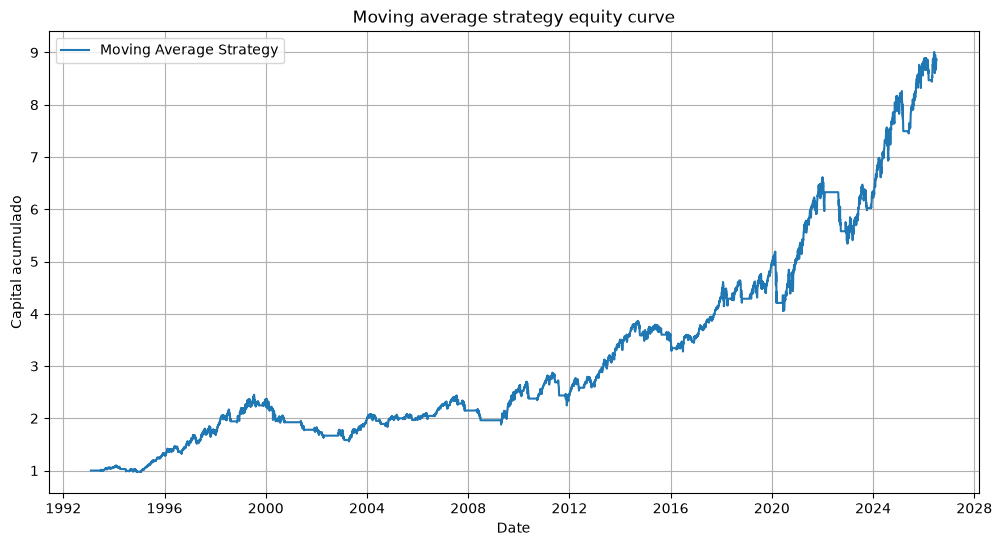

In [60]:
plt.figure(figsize=(12, 6))

plt.plot(ma_equity.index, ma_equity, label="Moving Average Strategy")

plt.title("Moving average strategy equity curve")
plt.xlabel("Date")
plt.ylabel("Capital acumulado")
plt.legend()
plt.grid(True)
plt.show()

## Curva de capital

La curva de capital muestra cómo habría evolucionado una unidad de capital invertida siguiendo la estrategia de medias móviles.

Cuando la estrategia está fuera del mercado, la curva no cambia porque la posición es `0`.

In [61]:
equity_comparison = compare_equity_curves({
    "Buy and Hold": buy_and_hold_equity,
    "Moving Average": ma_equity,
})

equity_comparison.tail()

,Buy and Hold,Moving Average
Date,,
2026-06-26,30.018413,8.669718
2026-06-29,30.512962,8.812550
2026-06-30,30.750560,8.881172
2026-07-01,30.708970,8.869160
2026-07-02,30.668616,8.857505


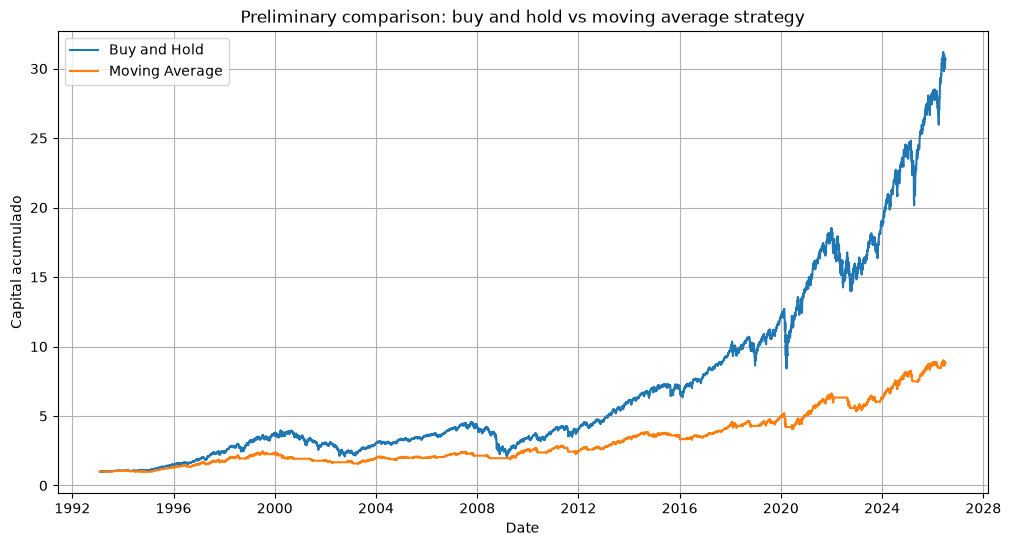

In [62]:
plt.figure(figsize=(12, 6))

for column in equity_comparison.columns:
    plt.plot(equity_comparison.index, equity_comparison[column], label=column)

plt.title("Preliminary comparison: buy and hold vs moving average strategy")
plt.xlabel("Date")
plt.ylabel("Capital acumulado")
plt.legend()
plt.grid(True)
plt.show()

## Comparación preliminar de curvas

Este gráfico compara la curva de capital de buy and hold con la curva de capital de la estrategia de medias móviles.

Esta es todavía una comparación inicial. En el Día 4 analizaré con más detalle rentabilidad, volatilidad y drawdown.

In [65]:
time_in_market = ma_position.mean()

time_in_market, time_in_market * 100

(np.float64(0.7326438421302901), np.float64(73.264384213029))

## Tiempo en mercado

La estrategia está invertida aproximadamente el 73.26% de los días.

Esto significa que no captura todos los rendimientos de SPY, sino solo los rendimientos de los días en los que la posición anterior era `1`.

## Análisis del Día 3

1. ¿Cuál es la rentabilidad total de la estrategia de medias móviles?

785.750533 desde el inicio de los datos

2. ¿Cuál es su rentabilidad anualizada?

6.746620 por ciento

3. ¿Cuál es su volatilidad anualizada?

12.246197 por ciento

4. ¿Cuál es su máximo drawdown?

-36.474684 por ciento

5. ¿La estrategia parece ganar más o menos que buy and hold?

Parece ganar menos

6. ¿La estrategia parece tener más o menos volatilidad que buy and hold?

Parece menos volátil

7. ¿Qué significa que la estrategia esté invertida solo una parte del tiempo?

Significa que hay días en los que vamos a retirar el capital que tengamos invertido en el activo, porque consideramos que la tendencia es bajista y vamos a perder dinero (es decir, observamos que la media a largo plazo es mayor que la de a corto plazo)

8. ¿Por qué `run_backtest` usa `position.shift(1)`?

Es porque tenemos que decidir la estrategia de cada dia en función de la comparación de medias del día anterior. No obstante, no veo dónde utilizo esto en mi código:

In [66]:

def run_moving_average_backtest(
    price: pd.Series,
    returns: pd.Series,
    short_window: int,
    long_window: int,
) -> tuple[pd.Series, pd.Series, pd.Series, pd.Series]:
    """
    Run a moving average strategy backtest.

    Parameters
    ----------
    price : pd.Series
        Price series.
    returns : pd.Series
        Asset returns.
    short_window : int
        Window used for the short moving average.
    long_window : int
        Window used for the long moving average.

    Returns
    -------
    tuple[pd.Series, pd.Series, pd.Series, pd.Series]
        Position, strategy returns, equity curve, and performance summary.
    """
    position_on_price_index = create_moving_average_position(
        price=price,
        short_window=short_window,
        long_window=long_window,
    )

    position = position_on_price_index.loc[returns.index].copy()

    validate_inputs(returns, position)

    strategy_returns, equity_curve = run_backtest(
        returns=returns,
        position=position,
    )

    summary = performance_summary(
        equity_curve=equity_curve,
        returns=strategy_returns,
    )

    return position, strategy_returns, equity_curve, summary

In [67]:
test_position, test_returns, test_equity, test_summary = run_moving_average_backtest(
    price=price,
    returns=returns,
    short_window=short_window,
    long_window=long_window,
)

test_summary * 100

Rentabilidad total         785.750533
Rentabilidad anualizada      6.746620
Volatilidad anualizada      12.246197
Máximo drawdown            -36.474684
dtype: float64

In [68]:
(test_equity - ma_equity).abs().max()

np.float64(0.0)

## Tarea extra

He creado una función `run_moving_average_backtest` que encapsula el flujo completo de la estrategia de medias móviles:

precio
→ posición
→ backtest
→ curva de capital
→ métricas.

Esta función permite repetir el backtest con distintas ventanas de medias móviles sin copiar todo el código.